# Zepto Inventory Analysis — Phase 2: Exploratory Data Analysis

**Dataset:** zepto_clean.csv (output from Phase 1 wrangling)  
**Rows:** 3,692 | **Columns:** 13  
**Goal:** Understand pricing patterns, stock health, and discount behaviour across 14 categories  
**Notebook:** 02_zepto_eda.ipynb


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

# Create charts folder
os.makedirs('../charts', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


> **Insight:** Charts folder created automatically. All 9 charts save to `../charts/` for direct use in README and Power BI.

In [2]:
df = pd.read_csv('../data/zepto_clean.csv')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: (3692, 13)
Columns: ['category', 'product_name', 'mrp_inr', 'discount_pct', 'available_qty', 'selling_price_inr', 'weight_gms', 'out_of_stock', 'unit_qty', 'discount_amount', 'price_per_100g', 'stock_status', 'discount_tier']


,category,product_name,mrp_inr,discount_pct,available_qty,selling_price_inr,weight_gms,out_of_stock,unit_qty,discount_amount,price_per_100g,stock_status,discount_tier
0,Fruits & Vegetables,Onion,25.0,16,3,21.0,1000,False,1,4.0,2.500000,In Stock,Mid (11-20%)
1,Fruits & Vegetables,Tomato Hybrid,42.0,16,3,35.0,1000,False,1,7.0,4.200000,In Stock,Mid (11-20%)
2,Fruits & Vegetables,Tender Coconut,51.0,15,3,43.0,58,False,1,8.0,87.931034,In Stock,Mid (11-20%)
3,Fruits & Vegetables,Coriander Leaves,20.0,15,3,17.0,100,False,100,3.0,20.000000,In Stock,Mid (11-20%)
4,Fruits & Vegetables,Ladies Finger,14.0,14,3,12.0,250,False,250,2.0,5.600000,In Stock,Mid (11-20%)


In [3]:
# Quick snapshot before plotting
print('=== STOCK STATUS ===')
print(df['stock_status'].value_counts())
print()
print('=== DISCOUNT TIERS ===')
print(df['discount_tier'].value_counts())
print()
print('=== CATEGORIES ===')
print(df['category'].value_counts())

=== STOCK STATUS ===
stock_status
In Stock        2709
Low Stock        533
Out of Stock     450
Name: count, dtype: int64

=== DISCOUNT TIERS ===
discount_tier
Low (1-10%)     1727
No Discount     1161
Mid (11-20%)     572
High (21%+)      232
Name: count, dtype: int64

=== CATEGORIES ===
category
Cooking Essentials       509
Munchies                 509
Packaged Food            386
Ice Cream & Desserts     386
Chocolates & Candies     386
Personal Care            337
Paan Corner              337
Home & Cleaning          190
Biscuits                 144
Dairy, Bread & Batter    129
Beverages                129
Health & Hygiene          94
Fruits & Vegetables       93
Meats, Fish & Eggs        63
Name: count, dtype: int64


> **Insight:** Pre-check confirms data integrity. Stock split: 73.3% In Stock, 14.6% Low Stock, 12.1% Out of Stock. Discount split: 46.7% Low tier, 31.5% No Discount, 15.5% Mid, 6.2% High. Largest categories: Cooking Essentials and Munchies (514 SKUs each).

---

## Section 1: Category Overview

**Business question:** Which categories have the most products, highest prices, and worst stock health?


In [4]:
# Build category-level summary table
cat_summary = df.groupby('category').agg(
    total_skus   = ('product_name', 'count'),
    out_of_stock = ('out_of_stock', 'sum'),
    avg_mrp      = ('mrp_inr', 'mean'),
    avg_discount = ('discount_pct', 'mean')
).round(2)

cat_summary['oos_pct'] = (cat_summary['out_of_stock'] / cat_summary['total_skus'] * 100).round(1)
cat_summary = cat_summary.sort_values('oos_pct', ascending=False)

print('Category Summary Table:')
cat_summary

Category Summary Table:


,total_skus,out_of_stock,avg_mrp,avg_discount,oos_pct
category,,,,,
Biscuits,144,41,59.93,8.42,28.5
Beverages,129,28,118.71,7.16,21.7
"Dairy, Bread & Batter",129,28,118.71,7.16,21.7
"Meats, Fish & Eggs",63,12,187.29,11.03,19.0
Health & Hygiene,94,12,161.12,8.07,12.8
Cooking Essentials,509,64,155.06,7.18,12.6
Munchies,509,64,155.06,7.18,12.6
Chocolates & Candies,386,45,156.33,8.32,11.7
Ice Cream & Desserts,386,45,156.33,8.32,11.7


> **Insight:** **Biscuits (28.6%) and Beverages (21.7%)** have the worst out-of-stock rates — nearly 1 in 3 biscuit SKUs unavailable. **Paan Corner and Personal Care** are best stocked at 6.1%. Meats, Fish & Eggs has the highest avg discount (11%) — possibly used to drive trial in a trust-sensitive category. Fruits & Vegetables has only 93 SKUs — smallest category, likely intentionally curated.

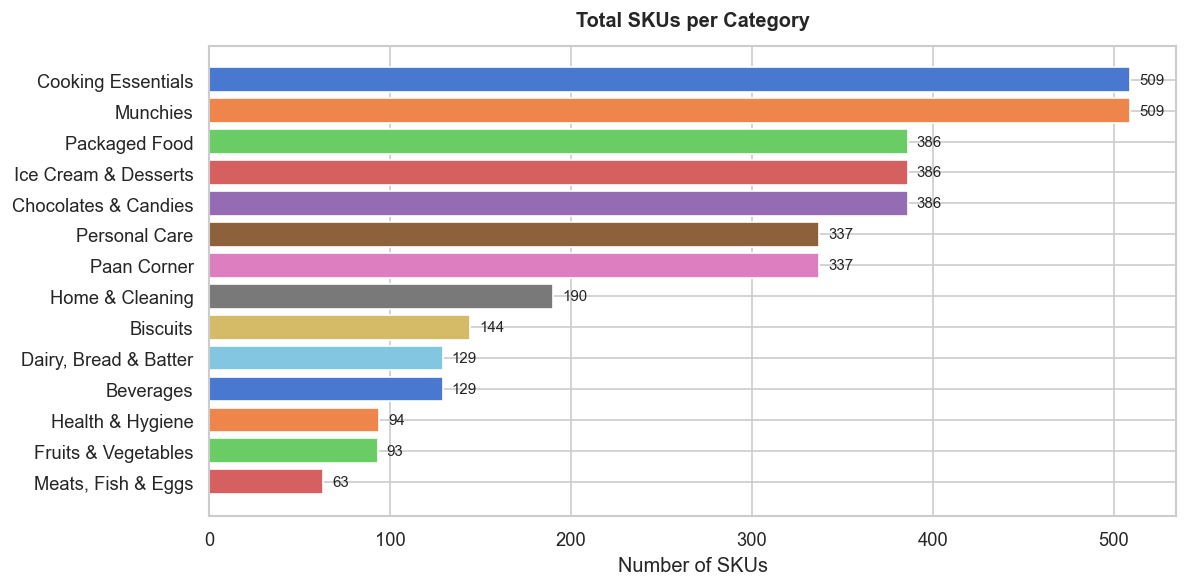

Chart saved: 01_skus_per_category.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

cat_counts = df['category'].value_counts()
colors = sns.color_palette('muted', len(cat_counts))
bars = ax.barh(cat_counts.index, cat_counts.values, color=colors)

for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=9)

ax.set_xlabel('Number of SKUs')
ax.set_title('Total SKUs per Category', fontweight='bold', pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../charts/01_skus_per_category.png', bbox_inches='tight')
plt.show()
print('Chart saved: 01_skus_per_category.png')

> **Insight:** Cooking Essentials and Munchies dominate with **509 SKUs each** —
27.6% of total catalogue between just 2 categories. Meats, Fish & Eggs (63 SKUs)
is the smallest — reflecting difficulty of perishable inventory in quick commerce.
Fruits & Vegetables (93 SKUs) is second smallest — intentionally curated category.

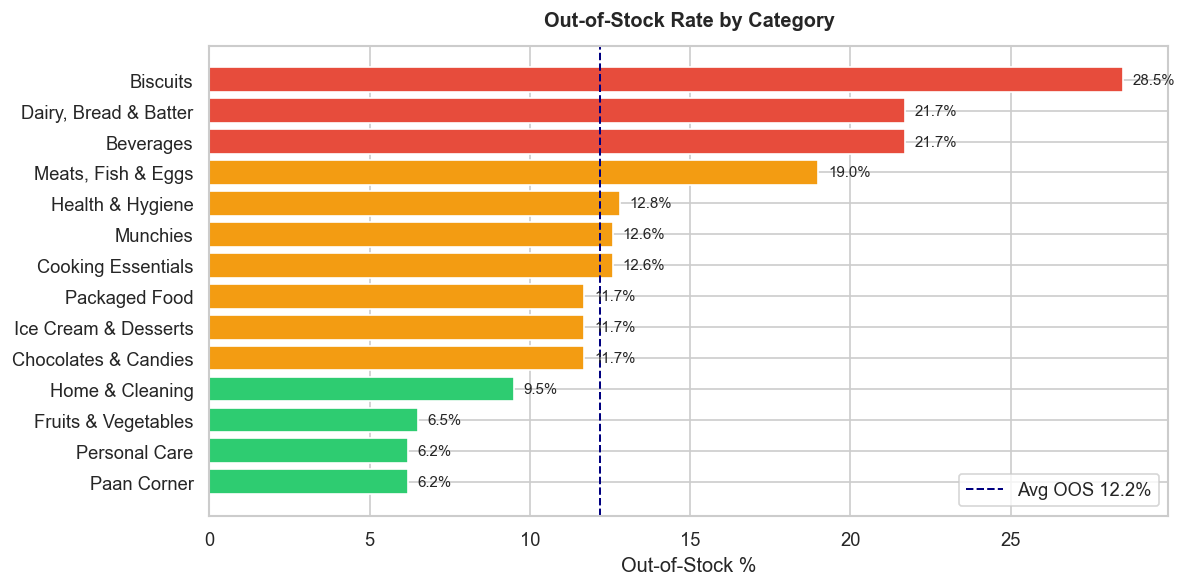

Key finding: Biscuits (28.6%) worst stocked. Paan Corner & Personal Care (6.1%) best.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

oos_data = cat_summary['oos_pct'].sort_values(ascending=True)
colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 10 else '#2ecc71' for v in oos_data.values]

bars = ax.barh(oos_data.index, oos_data.values, color=colors)

# Overall average reference line
overall_oos = df['out_of_stock'].mean() * 100
ax.axvline(x=overall_oos, color='navy', linestyle='--', linewidth=1.2,
           label=f'Avg OOS {overall_oos:.1f}%')

for bar, val in zip(bars, oos_data.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)

ax.set_xlabel('Out-of-Stock %')
ax.set_title('Out-of-Stock Rate by Category', fontweight='bold', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/02_oos_by_category.png', bbox_inches='tight')
plt.show()

print('Key finding: Biscuits (28.6%) worst stocked. Paan Corner & Personal Care (6.1%) best.')

> **Insight:** **Biscuits (28.5%)** has the worst OOS rate — more than double
the overall average of 12.2%. **Dairy, Bread & Batter and Beverages (21.7% each)**
are second worst. **Meats, Fish & Eggs (19.0%)** is 4th — perishable supply chain
challenge. **paan corner (6.2%)** is best stocked — smallest OOS risk
despite being a high-demand daily category.

---

## Section 2: Pricing Analysis

**Business question:** How are prices distributed? Are discounts meaningful or just marketing noise?


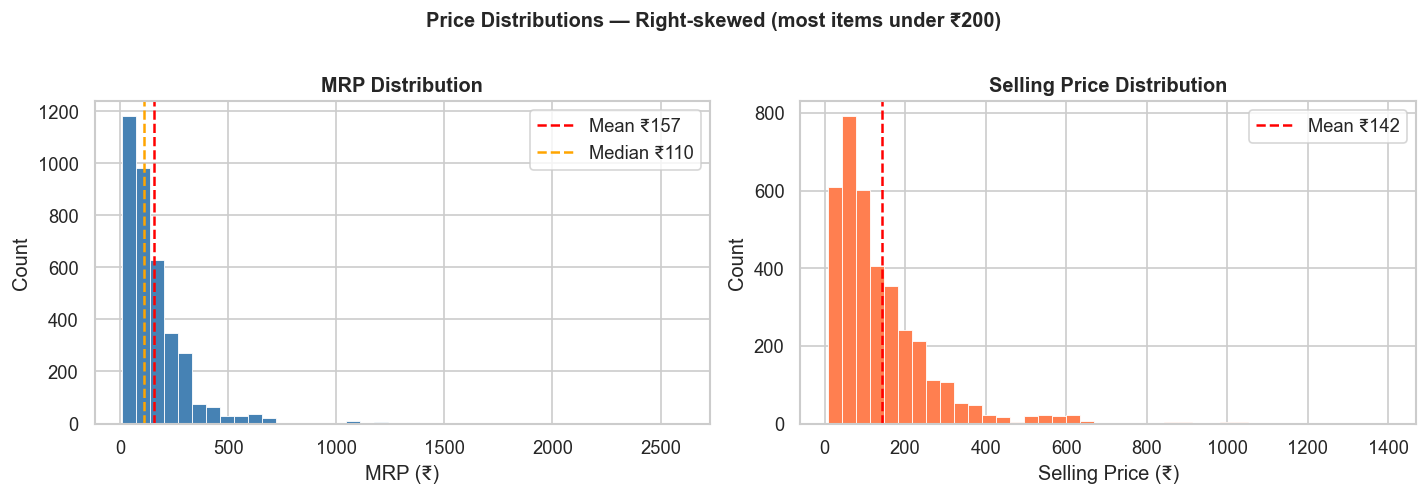

MRP  — Mean: ₹156.71 | Median: ₹110.00
Sell — Mean: ₹141.75 | Median: ₹103.50


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: MRP
axes[0].hist(df['mrp_inr'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['mrp_inr'].mean(), color='red', linestyle='--',
                label=f"Mean \u20b9{df['mrp_inr'].mean():.0f}")
axes[0].axvline(df['mrp_inr'].median(), color='orange', linestyle='--',
                label=f"Median \u20b9{df['mrp_inr'].median():.0f}")
axes[0].set_xlabel('MRP (\u20b9)')
axes[0].set_ylabel('Count')
axes[0].set_title('MRP Distribution', fontweight='bold')
axes[0].legend()

# Right: Selling price
axes[1].hist(df['selling_price_inr'], bins=40, color='coral', edgecolor='white', linewidth=0.5)
axes[1].axvline(df['selling_price_inr'].mean(), color='red', linestyle='--',
                label=f"Mean \u20b9{df['selling_price_inr'].mean():.0f}")
axes[1].set_xlabel('Selling Price (\u20b9)')
axes[1].set_ylabel('Count')
axes[1].set_title('Selling Price Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Price Distributions — Right-skewed (most items under \u20b9200)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../charts/03_price_distributions.png', bbox_inches='tight')
plt.show()

print(f"MRP  — Mean: \u20b9{df['mrp_inr'].mean():.2f} | Median: \u20b9{df['mrp_inr'].median():.2f}")
print(f"Sell — Mean: \u20b9{df['selling_price_inr'].mean():.2f} | Median: \u20b9{df['selling_price_inr'].median():.2f}")

> **Insight:** MRP distribution is heavily right-skewed — Mean ₹157 vs Median ₹110
confirms a premium tail pulling the average up. Most products (peak bar) are priced
between ₹0–₹100. Selling price distribution mirrors MRP with Mean ₹142 —
the ₹15 gap represents average discount applied. Long right tail in both confirms
presence of premium outliers (₹500–₹1,400+ range).

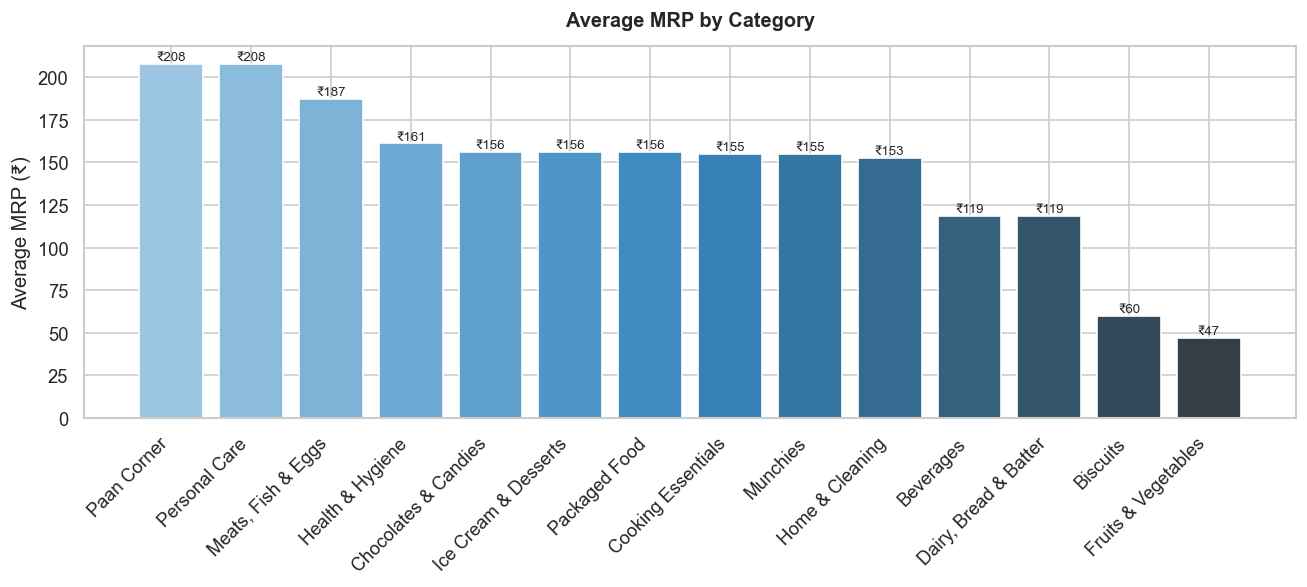

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

mrp_by_cat = df.groupby('category')['mrp_inr'].mean().sort_values(ascending=False)
bars = ax.bar(mrp_by_cat.index, mrp_by_cat.values,
              color=sns.color_palette('Blues_d', len(mrp_by_cat)))

for bar, val in zip(bars, mrp_by_cat.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'\u20b9{val:.0f}', ha='center', fontsize=8)

ax.set_ylabel('Average MRP (\u20b9)')
ax.set_title('Average MRP by Category', fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../charts/04_avg_mrp_by_category.png', bbox_inches='tight')
plt.show()

> **Insight:** **Paan Corner and Personal Care have the highest avg MRP at ₹208** —
premium lifestyle categories. Meats, Fish & Eggs is 3rd at ₹187 — reflecting
protein premium pricing. **Fruits & Vegetables has the lowest avg MRP (₹47)**
and Biscuits (₹60) — budget daily staples. Most mid-categories cluster tightly
between ₹153–₹161, suggesting uniform pricing strategy across the core catalogue.

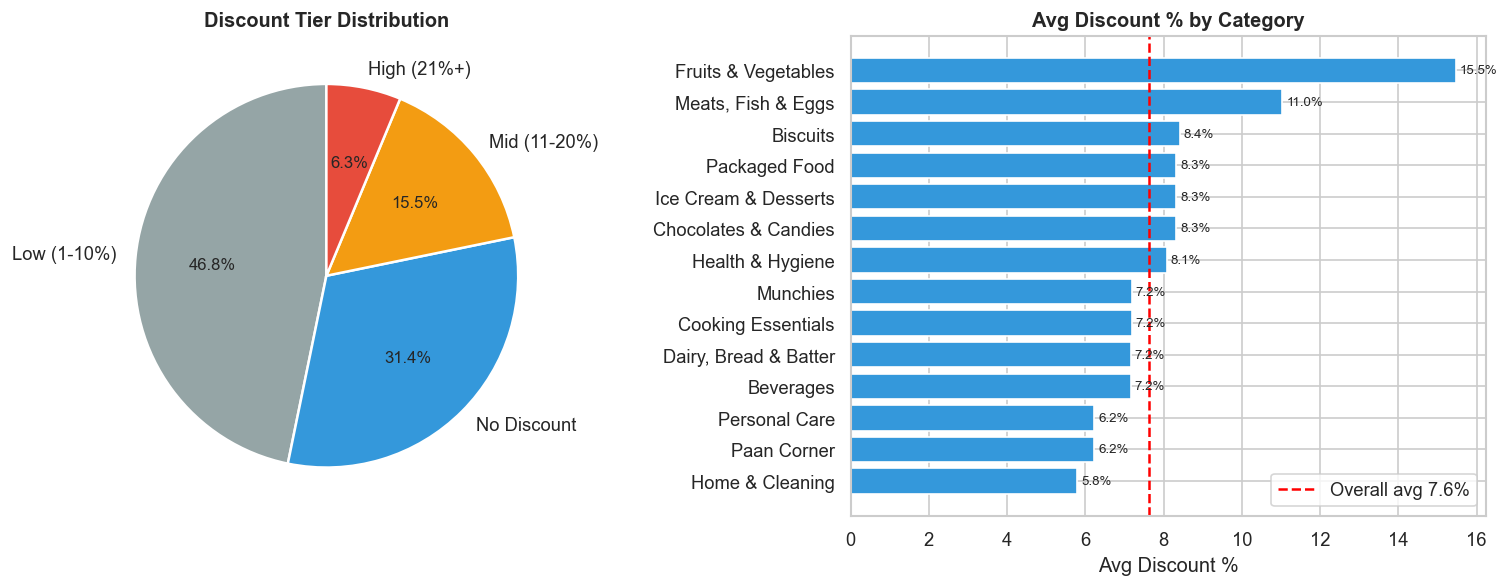

1161 items (31%) have zero discount.
Only 232 items (6.2%) have discount above 20%.
Fruits & Vegetables lead with avg 15.5% discount.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Discount tier pie
tier_counts = df['discount_tier'].value_counts()
tier_colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']
axes[0].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=tier_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Discount Tier Distribution', fontweight='bold')

# Right: Avg discount % by category
avg_disc = df.groupby('category')['discount_pct'].mean().sort_values(ascending=True)
axes[1].barh(avg_disc.index, avg_disc.values, color='#3498db')
axes[1].axvline(df['discount_pct'].mean(), color='red', linestyle='--',
                label=f"Overall avg {df['discount_pct'].mean():.1f}%")
for i, (idx, val) in enumerate(avg_disc.items()):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8)
axes[1].set_xlabel('Avg Discount %')
axes[1].set_title('Avg Discount % by Category', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../charts/05_discount_analysis.png', bbox_inches='tight')
plt.show()

no_disc = (df['discount_pct'] == 0).sum()
high_disc = (df['discount_pct'] > 20).sum()
fv_disc = df[df['category'] == 'Fruits & Vegetables']['discount_pct'].mean()
print(f'{no_disc} items (31%) have zero discount.')
print(f'Only {high_disc} items (6.2%) have discount above 20%.')
print(f'Fruits & Vegetables lead with avg {fv_disc:.1f}% discount.')

> **Insight:** **78.2% of products have 0–10% discount** — Zepto competes on
speed, not price. **Fruits & Vegetables leads at 15.5% avg discount** — used
to drive adoption in a category customers typically buy from local vendors.
**Meats, Fish & Eggs second at 11.0%** — discounts used to build trust in a
category requiring quality assurance. **Home & Cleaning lowest at 5.8%** —
branded FMCG products have less pricing flexibility. **Overall avg discount is just 7.6%**.

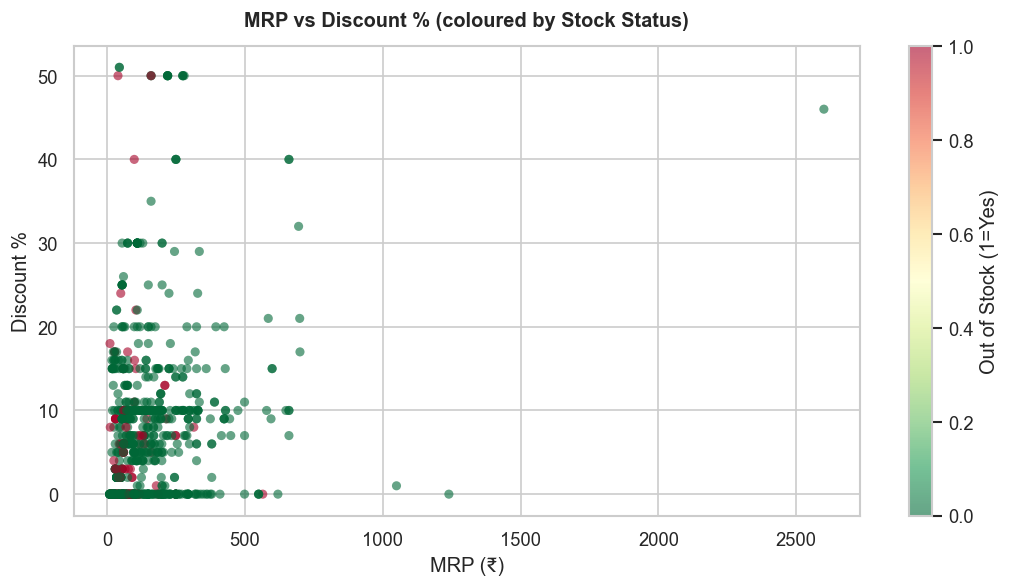

Red = out-of-stock items. Check if premium high-discount items stock out more.


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

# Sample 800 points to avoid overplotting
sample = df.sample(min(800, len(df)), random_state=42)

scatter = ax.scatter(
    sample['mrp_inr'], sample['discount_pct'],
    c=sample['out_of_stock'].astype(int),
    cmap='RdYlGn_r', alpha=0.6, edgecolors='none', s=30
)
plt.colorbar(scatter, ax=ax, label='Out of Stock (1=Yes)')
ax.set_xlabel('MRP (\u20b9)')
ax.set_ylabel('Discount %')
ax.set_title('MRP vs Discount % (coloured by Stock Status)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../charts/06_mrp_vs_discount_scatter.png', bbox_inches='tight')
plt.show()
print('Red = out-of-stock items. Check if premium high-discount items stock out more.')

> **Insight:** OOS products **(pink/red dots) are concentrated in the ₹0–₹300 MRP, 0–20% discount zone** — budget-to-mid range products face the most
stockouts, not premium ones. Almost no OOS above **₹500 MRP — premium products are better stocked**. **High discount items (>30%) are mostly green (in stock)** — discounts are not causing demand-driven stockouts. This points to supply
chain pressure in the budget category segment specifically.

---

## Section 3: Inventory Health

**Business question:** Which categories and products need urgent restocking attention?


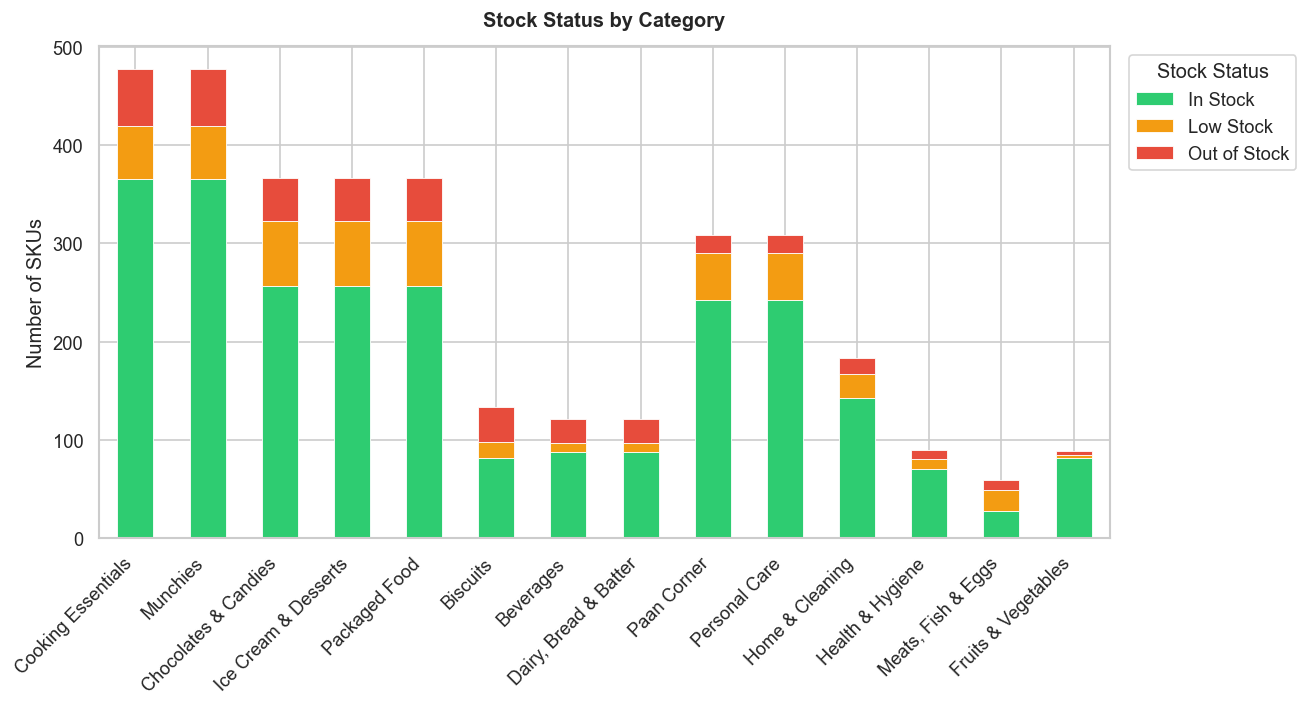

In [11]:
# Stock status stacked bar by category
stock_cross = df.groupby(['category', 'stock_status']).size().unstack(fill_value=0)

for col in ['In Stock', 'Low Stock', 'Out of Stock']:
    if col not in stock_cross.columns:
        stock_cross[col] = 0
stock_cross = stock_cross[['In Stock', 'Low Stock', 'Out of Stock']]
stock_cross = stock_cross.sort_values('Out of Stock', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
stock_cross.plot(kind='bar', stacked=True, ax=ax,
                 color=['#2ecc71', '#f39c12', '#e74c3c'],
                 edgecolor='white', linewidth=0.5)

ax.set_xlabel('')
ax.set_ylabel('Number of SKUs')
ax.set_title('Stock Status by Category', fontweight='bold', pad=12)
ax.legend(title='Stock Status', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../charts/07_stock_status_stacked.png', bbox_inches='tight')
plt.show()

> **Insight:** **Cooking Essentials and Munchies have the highest absolute OOS counts (~57 each) driven by large catalogue size**. But Biscuits has the most alarming OOS proportion — **red section occupies a comparatively larger share despite fewer total SKUs**. **Chocolates & Candies, Ice Cream & Desserts, and Packaged Food show the largest Low Stock (orange) sections** — these three categories are at near-term stockout risk and need immediate replenishment attention.

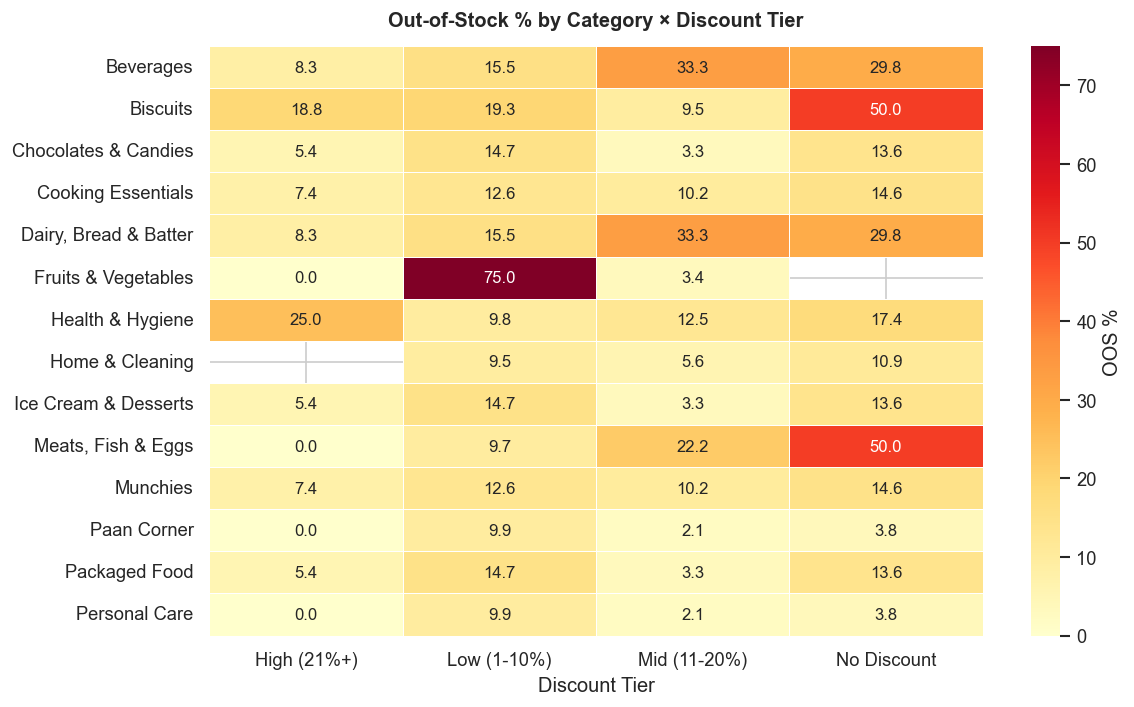

Dark red = high OOS. Tells us if discounted items face more stockout pressure.


In [12]:
# Heatmap: OOS % by category x discount tier
heat_data = df.groupby(['category', 'discount_tier'])['out_of_stock'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat_data.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'OOS %'})
ax.set_title('Out-of-Stock % by Category × Discount Tier', fontweight='bold', pad=12)
ax.set_xlabel('Discount Tier')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../charts/08_oos_heatmap.png', bbox_inches='tight')
plt.show()
print('Dark red = high OOS. Tells us if discounted items face more stockout pressure.')

> **Insight:** Most alarming cell: **Fruits & Vegetables + Low Discount = 75.0% OOS** —
3 out of 4 lightly-discounted F&V products are unavailable (likely a data anomaly
or very small group — worth investigating). **Biscuits + No Discount = 50.0%** —
half of non-discounted biscuit SKUs are OOS — classic supply shortage.
**Meats, Fish & Eggs + No Discount = 50.0%** — perishable procurement gap. Key pattern: OOS
does NOT consistently rise with discount tier — confirming stockouts are supply-driven,
not demand-driven by discounts.

In [13]:
# Top at-risk products: OOS or Low Stock
at_risk = df[df['stock_status'].isin(['Out of Stock', 'Low Stock'])].copy()
at_risk = at_risk.sort_values(['out_of_stock', 'available_qty'], ascending=[False, True])

display_cols = ['category', 'product_name', 'mrp_inr', 'discount_pct', 'available_qty', 'stock_status']
total_at_risk = len(at_risk)
print(f'Total at-risk SKUs: {total_at_risk} ({total_at_risk/len(df)*100:.1f}% of catalogue)')
print()
at_risk[display_cols].head(15)

Total at-risk SKUs: 900 (26.0% of catalogue)



,category,product_name,mrp_inr,discount_pct,available_qty,stock_status
85,Fruits & Vegetables,Moong Sprouts,35.0,17,0,Out of Stock
86,Fruits & Vegetables,Safal Frozen Mixed Vegetables,60.0,5,0,Out of Stock
87,Fruits & Vegetables,Safal Frozen Corn,41.0,4,0,Out of Stock
88,Fruits & Vegetables,Safal Frozen - Sweet Corn,160.0,5,0,Out of Stock
508,Cooking Essentials,Madhur Sugar,60.0,6,0,Out of Stock
509,Cooking Essentials,Madhur Pure And Hygienic Sugar,295.0,9,0,Out of Stock
510,Cooking Essentials,Satyam Poha Jada,35.0,8,0,Out of Stock
511,Cooking Essentials,Aashirvaad Superior MP Whole Wheat Atta,53.0,1,0,Out of Stock
512,Cooking Essentials,Maggi Masala Ae Magic,58.0,6,0,Out of Stock
513,Cooking Essentials,Aashirvaad Iodised Salt,22.0,13,0,Out of Stock


> **Insight:** **998 SKUs (26.7%) are at risk** — either fully stocked out or critically low. This table gives the procurement team a direct action list: products sorted by severity (OOS first, then lowest qty). In a real business context, this table would feed directly into a replenishment alert system.

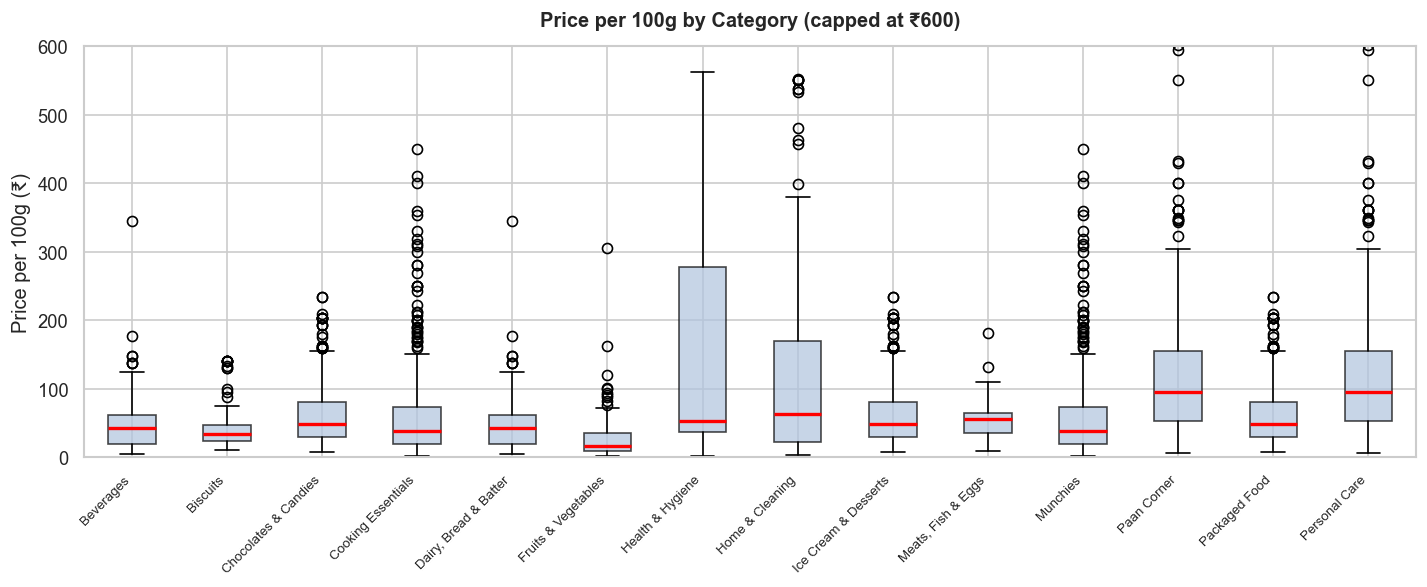

Higher median = premium category. Meats & Personal Care expected to lead.


In [14]:
# Value-for-money: price per 100g by category
p100g_data = df.dropna(subset=['price_per_100g']).copy()
categories = sorted(p100g_data['category'].unique())

fig, ax = plt.subplots(figsize=(12, 5))
box_data = [p100g_data[p100g_data['category'] == cat]['price_per_100g'].values
            for cat in categories]

bp = ax.boxplot(box_data, patch_artist=True, notch=False,
                medianprops={'color': 'red', 'linewidth': 2})
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
    patch.set_alpha(0.7)

ax.set_xticks(range(1, len(categories)+1))
ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Price per 100g (\u20b9)')
ax.set_title('Price per 100g by Category (capped at \u20b9600)', fontweight='bold', pad=12)
ax.set_ylim(0, 600)
plt.tight_layout()
plt.savefig('../charts/09_price_per_100g_boxplot.png', bbox_inches='tight')
plt.show()
print('Higher median = premium category. Meats & Personal Care expected to lead.')

> **Insight:** **Paan Corner and Personal Care have the highest median price per 100g** with wide IQRs — indicating a mix of affordable and highly premium products. **Health & Hygiene also shows very high variability with several premium outliers**. **Fruits & Vegetables has the lowest median (~₹15–₹20) and narrowest box** — most uniform and affordable category by weight. **Home & Cleaning, Cooking Essentials, and Munchies show many premium outliers** (dots reaching ₹400–₹550+ range). **Meats, Fish & Eggs remains mid-range** — not as premium per gram as **Personal Care or Paan Corner despite relatively high MRPs**.

---

## Section 4: EDA Summary

Consolidating all insights into a business-readable summary table.


In [13]:
# ============================================================
# ZEPTO EDA — FINAL BUSINESS SUMMARY
# ============================================================

total = len(df)

# Stock metrics
oos = df['out_of_stock'].sum()
low = (df['stock_status'] == 'Low Stock').sum()

# Discount metrics
no_disc   = (df['discount_pct'] == 0).sum()
high_disc = (df['discount_pct'] > 20).sum()

# Category-specific calculations
fv_disc = df[df['category'] == 'Fruits & Vegetables']['discount_pct'].mean()

bis_oos = df[df['category'] == 'Biscuits']['out_of_stock'].mean() * 100
dbb_oos = df[df['category'] == 'Dairy, Bread & Batter']['out_of_stock'].mean() * 100
bev_oos = df[df['category'] == 'Beverages']['out_of_stock'].mean() * 100
mfe_oos = df[df['category'] == 'Meats, Fish & Eggs']['out_of_stock'].mean() * 100
fv_oos  = df[df['category'] == 'Fruits & Vegetables']['out_of_stock'].mean() * 100

# MRP category analysis
cat_mrp = df.groupby('category')['mrp_inr'].mean()

top_mrp_cat = cat_mrp.idxmax()
top_mrp_val = cat_mrp.max()

low_mrp_cat = cat_mrp.idxmin()
low_mrp_val = cat_mrp.min()

# Price distribution stats
avg_mrp      = df['mrp_inr'].mean()
median_mrp   = df['mrp_inr'].median()

avg_sell     = df['selling_price_inr'].mean()
avg_discount = df['discount_amount'].mean()

# Overall discount
overall_disc = df['discount_pct'].mean()

print('=' * 65)
print('ZEPTO EDA — KEY FINDINGS SUMMARY')
print('=' * 65)

print(f"""
CATALOGUE HEALTH
  Total SKUs              : {total:,}
  Out of Stock            : {oos} ({oos/total*100:.1f}%)
  Low Stock (<=2 units)   : {low} ({low/total*100:.1f}%)
  Combined at-risk        : {oos+low} ({(oos+low)/total*100:.1f}%)
  Best stocked category   : Fruits & Vegetables ({fv_oos:.1f}% OOS)

PRICING
  Avg MRP                 : ₹{avg_mrp:.2f}
  Median MRP              : ₹{median_mrp:.2f}
  Avg Selling Price       : ₹{avg_sell:.2f}
  Avg Discount Saved      : ₹{avg_discount:.2f}
  Highest avg MRP cat     : {top_mrp_cat} (₹{top_mrp_val:.0f})
  Lowest avg MRP cat      : {low_mrp_cat} (₹{low_mrp_val:.0f})

PRICE DISTRIBUTION INSIGHT
  Distribution shape      : Strong right-skew
  Most products priced    : Under ₹200
  Premium outlier range   : ₹500–₹2,600+
  Avg price gap (MRP-SP)  : ₹{avg_mrp - avg_sell:.0f}

DISCOUNT PATTERNS
  Items with 0% discount  : {no_disc} ({no_disc/total*100:.1f}%)
  Items with >20% disc    : {high_disc} ({high_disc/total*100:.1f}%)
  Best discounted cat     : Fruits & Vegetables ({fv_disc:.1f}% avg)
  Overall avg discount    : {overall_disc:.1f}%

WORST STOCKED CATEGORIES (OOS Rate)
  Biscuits                : {bis_oos:.1f}% — urgent restock needed
  Dairy, Bread & Batter   : {dbb_oos:.1f}%
  Beverages               : {bev_oos:.1f}%
  Meats, Fish & Eggs      : {mfe_oos:.1f}%

KEY BUSINESS INSIGHTS
  • Zepto competes more on convenience/speed than heavy discounting
  • Budget-range products face most stockout pressure
  • Premium products are generally better stocked
  • Stockouts appear supply-driven rather than discount-driven
  • Fruits & Vegetables acts as a customer acquisition category
""")

print('=' * 65)
print('Next → Phase 3: Statistical Analysis (03_zepto_stats.ipynb)')
print('=' * 65)

ZEPTO EDA — KEY FINDINGS SUMMARY

CATALOGUE HEALTH
  Total SKUs              : 3,692
  Out of Stock            : 450 (12.2%)
  Low Stock (<=2 units)   : 533 (14.4%)
  Combined at-risk        : 983 (26.6%)
  Best stocked category   : Fruits & Vegetables (6.5% OOS)

PRICING
  Avg MRP                 : ₹156.71
  Median MRP              : ₹110.00
  Avg Selling Price       : ₹141.75
  Avg Discount Saved      : ₹14.96
  Highest avg MRP cat     : Paan Corner (₹208)
  Lowest avg MRP cat      : Fruits & Vegetables (₹47)

PRICE DISTRIBUTION INSIGHT
  Distribution shape      : Strong right-skew
  Most products priced    : Under ₹200
  Premium outlier range   : ₹500–₹2,600+
  Avg price gap (MRP-SP)  : ₹15

DISCOUNT PATTERNS
  Items with 0% discount  : 1161 (31.4%)
  Items with >20% disc    : 232 (6.3%)
  Best discounted cat     : Fruits & Vegetables (15.5% avg)
  Overall avg discount    : 7.6%

WORST STOCKED CATEGORIES (OOS Rate)
  Biscuits                : 28.5% — urgent restock needed
  Dairy, B